#Relly Erlinda
#Data Analyst Project: Business Decision Research

#Data Preparation

Importing Data dan Inspection

In [1]:
import pandas as pd
df = pd.read_csv('data_retail.csv', sep=';')

In [2]:
#Mencetak data 5 teratas
print('Lima data teratas:')
print(df.head())

Lima data teratas:
   no  Row_Num  Customer_ID Product  First_Transaction  Last_Transaction  \
0   1        1        29531   Jaket      1466304274396     1538718482608   
1   2        2        29531  Sepatu      1406077331494     1545735761270   
2   3        3       141526     Tas      1493349147000     1548322802000   
3   4        4       141526   Jaket      1493362372547     1547643603911   
4   5        5        37545  Sepatu      1429178498531     1542891221530   

   Average_Transaction_Amount  Count_Transaction  
0                     1467681                 22  
1                     1269337                 41  
2                      310915                 30  
3                      722632                 27  
4                     1775036                 25  


In [3]:
#Mencetak info dataset
print('\nInfo dataset:')
print(df.info())


Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   no                          100000 non-null  int64 
 1   Row_Num                     100000 non-null  int64 
 2   Customer_ID                 100000 non-null  int64 
 3   Product                     100000 non-null  object
 4   First_Transaction           100000 non-null  int64 
 5   Last_Transaction            100000 non-null  int64 
 6   Average_Transaction_Amount  100000 non-null  int64 
 7   Count_Transaction           100000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 6.1+ MB
None


Data Cleansing

Dua kolom yang menunjukkan terjadinya transaksi tidak bertipe datetime, sehingga harus diubah kedua kolom tersebut ke tipe data datetime.

In [4]:
# Kolom First_Transaction
df['First_Transaction'] = pd.to_datetime(df['First_Transaction']/1000, unit='s', origin='1970-01-01')
# Kolom Last_Transaction
df['Last_Transaction']=pd.to_datetime(df['Last_Transaction']/1000,unit='s', origin ='1970-01-01')

print('Lima data teratas:')
print(df.head())

print('\nInfo dataset:')
print(df.info())

Lima data teratas:
   no  Row_Num  Customer_ID Product             First_Transaction  \
0   1        1        29531   Jaket 2016-06-19 02:44:34.395999908   
1   2        2        29531  Sepatu 2014-07-23 01:02:11.493999958   
2   3        3       141526     Tas 2017-04-28 03:12:27.000000000   
3   4        4       141526   Jaket 2017-04-28 06:52:52.546999931   
4   5        5        37545  Sepatu 2015-04-16 10:01:38.530999899   

               Last_Transaction  Average_Transaction_Amount  Count_Transaction  
0 2018-10-05 05:48:02.608000040                     1467681                 22  
1 2018-12-25 11:02:41.269999981                     1269337                 41  
2 2019-01-24 09:40:02.000000000                      310915                 30  
3 2019-01-16 13:00:03.911000013                      722632                 27  
4 2018-11-22 12:53:41.529999970                     1775036                 25  

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries,

Churn Customer

Untuk menentukan churn customers, maka harus mencari transaksi paling terakhir kapan dilakukan dan mengklasifikasikan mana customer yang berstatus chrun dan mana yang tidak

In [5]:
#Pengecekan transaksi terakhir dalam dataset
print(max(df['Last_Transaction']))

2019-02-01 23:57:57.286000013


In [6]:
#Mengklasifikasikan customer yang berstatus churn atau tidak
df.loc[df['Last_Transaction'] <= '2018-08-01', 'is_churn'] = True
df.loc[df['Last_Transaction'] > '2018-08-01', 'is_churn'] = False
print('Lima dara teratas:')
print(df.head())

Lima dara teratas:
   no  Row_Num  Customer_ID Product             First_Transaction  \
0   1        1        29531   Jaket 2016-06-19 02:44:34.395999908   
1   2        2        29531  Sepatu 2014-07-23 01:02:11.493999958   
2   3        3       141526     Tas 2017-04-28 03:12:27.000000000   
3   4        4       141526   Jaket 2017-04-28 06:52:52.546999931   
4   5        5        37545  Sepatu 2015-04-16 10:01:38.530999899   

               Last_Transaction  Average_Transaction_Amount  \
0 2018-10-05 05:48:02.608000040                     1467681   
1 2018-12-25 11:02:41.269999981                     1269337   
2 2019-01-24 09:40:02.000000000                      310915   
3 2019-01-16 13:00:03.911000013                      722632   
4 2018-11-22 12:53:41.529999970                     1775036   

   Count_Transaction is_churn  
0                 22    False  
1                 41    False  
2                 30    False  
3                 27    False  
4                 25    Fal

Menghapus kolom yang tidak diperlukan

In [7]:
#Menghapus kolom yang tidak diperlukan
df = df.drop(columns=['no', 'Row_Num'], errors='ignore')
print(df.head())

   Customer_ID Product             First_Transaction  \
0        29531   Jaket 2016-06-19 02:44:34.395999908   
1        29531  Sepatu 2014-07-23 01:02:11.493999958   
2       141526     Tas 2017-04-28 03:12:27.000000000   
3       141526   Jaket 2017-04-28 06:52:52.546999931   
4        37545  Sepatu 2015-04-16 10:01:38.530999899   

               Last_Transaction  Average_Transaction_Amount  \
0 2018-10-05 05:48:02.608000040                     1467681   
1 2018-12-25 11:02:41.269999981                     1269337   
2 2019-01-24 09:40:02.000000000                      310915   
3 2019-01-16 13:00:03.911000013                      722632   
4 2018-11-22 12:53:41.529999970                     1775036   

   Count_Transaction is_churn  
0                 22    False  
1                 41    False  
2                 30    False  
3                 27    False  
4                 25    False  


#Data Visualization

Customer acquisition by year

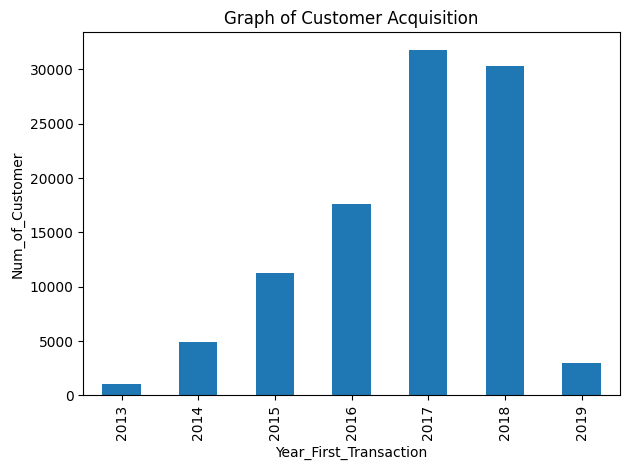

In [8]:
import matplotlib.pyplot as plt

#Kolom tahun transaksi pertama
df['Year_First_Transaction']=df['First_Transaction'].dt.year

#Kolom tahun transaksi terakhir
df['Year_Last_Transaction']=df['Last_Transaction'].dt.year

df_year = df.groupby(['Year_First_Transaction'])['Customer_ID'].count()
df_year.plot(x='Year_First_Transaction', y='Customer_ID', kind='bar', title='Graph of Customer Acquisition')
plt.xlabel('Year_First_Transaction')
plt.ylabel('Num_of_Customer')
plt.tight_layout()
plt.show()

Insight:

Jumlah customer baru meningkat dari 2013 samapi 2017, lalu mulai menurun di 2018 dan turun drastis di 2019. Ini menunjukkan bahwa kemampuan bisnis dalam menarik customer baru semakin melemah setelah 2017.

Rekomendasi:
- Meningkatkan kembali campaign marketing yang efektif seperti tahun 2017
- Memperkuat digitalk marketing dan promo untuk customer baru
- Menggunakan program referral untuk menarik customer

Transaction by year

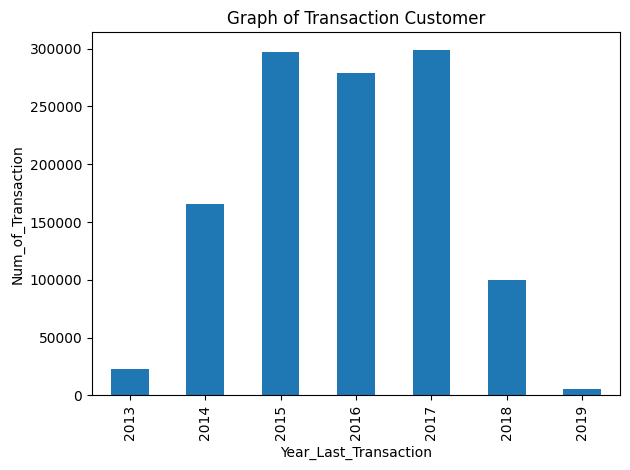

In [9]:
plt.clf()
df_year = df.groupby(['Year_First_Transaction'])['Count_Transaction'].sum()
df_year.plot(x='Year_First_Transaction', y='Count_Transaction', kind='bar', title='Graph of Transaction Customer')
plt.xlabel('Year_Last_Transaction')
plt.ylabel('Num_of_Transaction')
plt.tight_layout()
plt.show()

Insight:

Jumlah transaksi mengikuti pola yang sama, yaitu naik sampai 2017 dan menurun di 2018-2019. Ini menunjukkan bahwa tidak hanya customer baru yang berkurang, tetapi juga customer lama semakin jarang melakukan transaksi.

Rekomendasi:
- Memberikan promo khusus untuk repeat order
- Membuat loyalty program
- Mengirim reminder atau penawaran ke customer yang sudah lama tidak berbelanja

Average transaction amount by year

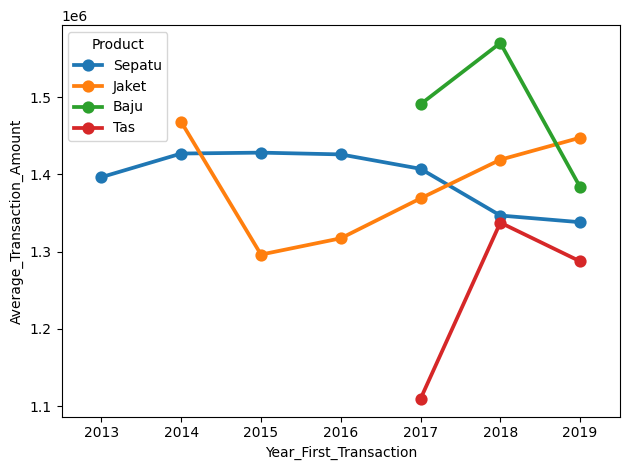

In [10]:
import seaborn as sns

plt.clf()
sns.pointplot(data = df.groupby(['Product','Year_First_Transaction']).mean().reset_index(),
              x='Year_First_Transaction',
              y='Average_Transaction_Amount',
              hue='Product')
plt.tight_layout()
plt.show()

Insight:

Produk sepatu paling stabil dan menjadi kontributor utama. Jaket menunjukkan tren meningkat sehingga berpotensi dikembangkan. Sementara baju dan tas cenderung tidak stabil dan kemungkinan dipengaruhi tren atau belum menemukan pasar yang tepat.

Rekomendasi:
- Jadikan sepatu sebagai produk utama dalam strategi penjualan
- Kembangkan jaket karena sedang menunjukkan tren positif
- Evaluasi strategi untuk tas dan baju, misal dengan mengikuti tren pasar

Proporsi churned customer untuk setiap produk

<Figure size 640x480 with 0 Axes>

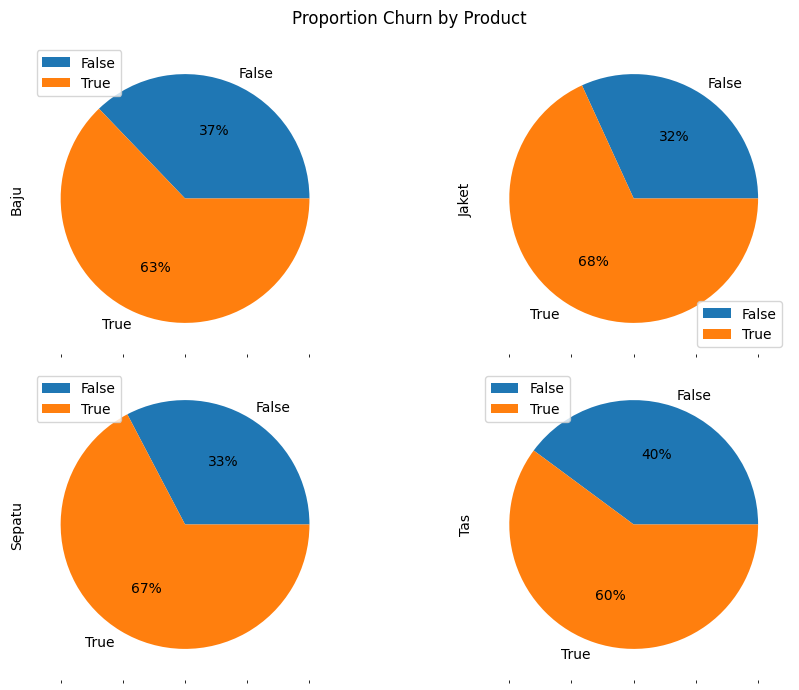

In [11]:
plt.clf()
# Melakukan pivot data dengan pivot_table
df_piv = df.pivot_table(index='is_churn',
                        columns='Product',
                        values='Customer_ID',
                        aggfunc='count',
                        fill_value=0)

# Mendapatkan Proportion Churn by Product
plot_product = df_piv.count().sort_values(ascending=False).head(5).index

# Plot pie chartnya
df_piv = df_piv.reindex(columns=plot_product)
df_piv.plot.pie(subplots=True,
                figsize=(10, 7),
                layout=(-1, 2),
                autopct='%1.0f%%',
                title='Proportion Churn by Product')

plt.tight_layout()
plt.show()

Insight:

Semua produk memiliki tingkat churn yang tinggi sekitar 60%-68%. Produk jaket dan sepatu memiliki churn paling tinggi, sedangkan tas sedikit lebih rendah. Ini menunjukkan sebagain besar customer tidak kembali bertransaksi di semua kategori produk.

Rekomendasi:
- Memberikan promo khusus setelah pembelian pertama
- Follow up ke customer setelah transaksi
- Personalisasi penawaran berdasarkan produk yang pernah dibeli

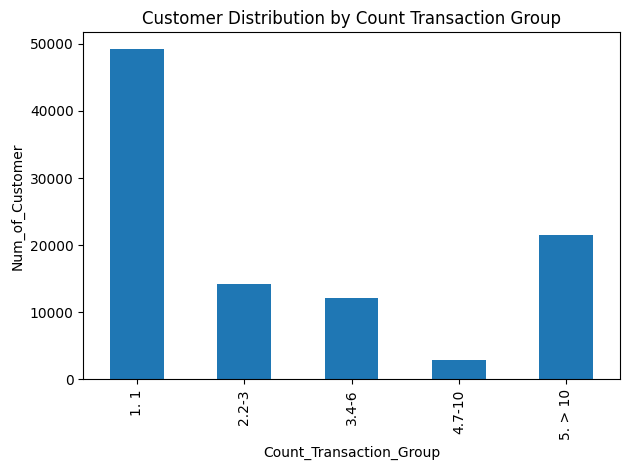

In [12]:
plt.clf()
# Kategorisasi jumlah transaksi
def func(row):
    if row['Count_Transaction'] == 1:
        val = '1. 1'
    elif (row['Count_Transaction'] > 1 and row['Count_Transaction'] <= 3):
        val ='2.2-3'
    elif (row['Count_Transaction'] > 3 and row['Count_Transaction'] <= 6):
        val ='3.4-6'
    elif (row['Count_Transaction'] > 6 and row['Count_Transaction'] <= 10):
        val ='4.7-10'
    else:
        val ='5. > 10'
    return val

# Menambahkan kolom baru
df['Count_Transaction_Group'] = df.apply(func, axis=1)

df_year = df.groupby(['Count_Transaction_Group'])['Customer_ID'].count()
df_year.plot(x='Count_Transaction_Group', y='Customer_ID', kind='bar', title='Customer Distribution by Count Transaction Group')
plt.xlabel('Count_Transaction_Group')
plt.ylabel('Num_of_Customer')
plt.tight_layout()
plt.show()

Insight:

Sebagian besar customer hanya melakukan 1 transaksi saja, dan jumlah customer semakin sedikit seiring meingkatnya jumlah transaksi. Ini menunjukkan mayoritas customer adalah one-time buyer (tidak repeat order)

Rekomendasi:
- Berikan diskon untuk pembelian kedua
- Membuat program membership
- Menawarkan bundling produk agar customer belanja lebih dari sekali

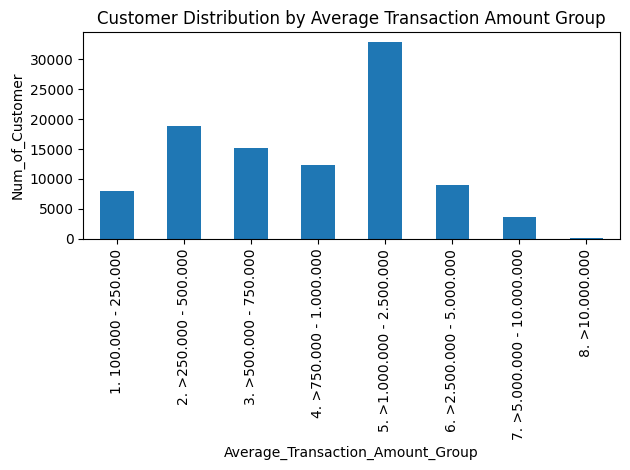

In [13]:
# Kategorisasi rata-rata besar transaksi
def f(row):
    if (row['Average_Transaction_Amount'] >= 100000 and row['Average_Transaction_Amount'] <=250000):
        val ='1. 100.000 - 250.000'
    elif (row['Average_Transaction_Amount'] > 250000 and row['Average_Transaction_Amount'] <= 500000):
        val ='2. >250.000 - 500.000'
    elif (row['Average_Transaction_Amount'] > 500000 and row['Average_Transaction_Amount'] <= 750000):
        val ='3. >500.000 - 750.000'
    elif (row['Average_Transaction_Amount'] > 750000 and row['Average_Transaction_Amount'] <= 1000000):
        val ='4. >750.000 - 1.000.000'
    elif (row['Average_Transaction_Amount'] > 1000000 and row['Average_Transaction_Amount'] <= 2500000):
        val ='5. >1.000.000 - 2.500.000'
    elif (row['Average_Transaction_Amount'] > 2500000 and row['Average_Transaction_Amount'] <= 5000000):
        val ='6. >2.500.000 - 5.000.000'
    elif (row['Average_Transaction_Amount'] > 5000000 and row['Average_Transaction_Amount'] <= 10000000):
        val ='7. >5.000.000 - 10.000.000'
    else:
        val ='8. >10.000.000'
    return val
# Menambahkan kolom baru
df['Average_Transaction_Amount_Group'] = df.apply(f, axis=1)

df_year = df.groupby(['Average_Transaction_Amount_Group'])['Customer_ID'].count()
df_year.plot(x='Average_Transaction_Amount_Group', y='Customer_ID', kind='bar', title='Customer Distribution by Average Transaction Amount Group')
plt.xlabel('Average_Transaction_Amount_Group')
plt.ylabel('Num_of_Customer')
plt.tight_layout()
plt.show()

Insight:

Sebagian besar customer berada di nilai transaksi menengah yaitu sekitar 1juta-2,5 juta. Sangat sedikit customer dengan transaksi tinggi (> 5juta). Artinya, kontribusi terbesar datang dari customer dengan nilai belanja sedang, bukan high spender.

Rekomendasi:
- Buat promo minimum pembelian
- Bundling produk
- Upselling ke produk yang lebih premium

#Modelling

In [14]:
# Feature column: Year_Diff
df['Year_Diff'] = df['Year_Last_Transaction'] - df['Year_First_Transaction']

# Drop rows with NaN values in the target or feature columns
df_cleaned = df.dropna(subset=['is_churn', 'Average_Transaction_Amount', 'Count_Transaction', 'Year_Diff'])

# Nama-nama feature columns
feature_columns = ['Average_Transaction_Amount', 'Count_Transaction', 'Year_Diff']

# Features variable
X = df_cleaned[feature_columns]

# Target variable
y = df_cleaned['is_churn']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [19]:
# model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

#Inisialisasi model logreg
logreg = LogisticRegression()

# Convert y_train and y_test to integer type (0 and 1)
y_train_converted = y_train.astype(int)
y_test_converted = y_test.astype(int)

#Fit model dengan data
logreg.fit(X_train, y_train_converted)

#Model prediksi
y_pred = logreg.predict(X_test)

#Evaluasi model menggunakan confusion matrix
cnf_matrix = confusion_matrix(y_test_converted, y_pred)
print("Confusion matrix:\n", cnf_matrix)

Confusion matrix:
 [[ 3426  4905]
 [  994 15675]]


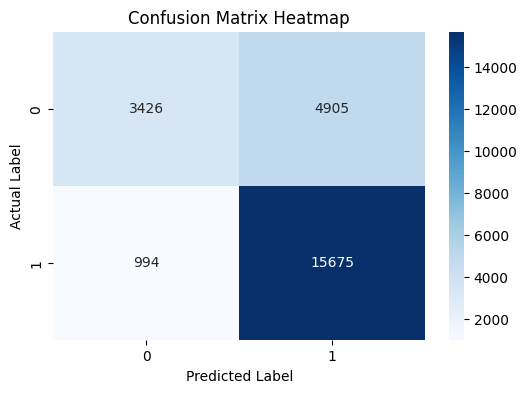

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(cnf_matrix,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

Prediksi benar:
- 15675 --> customer churn & berhasil di prediksi churn
- 3426 --> customer tidak churn & di prediksi tidak churn

Prediksi salah:
- 4905 --> tidak churn tapi di prediksi churn
- 994 --> churn tapi tidak terdeteksi

Model mampu mendeteksi sebagian besar customer yang churn dengan cukup baik, terlihat dari jumlah prediksi benar yang tinggi. Namun, masin terdapat sejumlah customer yang sebenarnya tidak churn tetapi diprediksi churn, sehingga perlu diperhatikan efisiensi dalam pembelian promosi.

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test_converted, y_pred))
print("Precision:", precision_score(y_test_converted, y_pred))
print("Recall:", recall_score(y_test_converted, y_pred))

Accuracy: 0.76404
Precision: 0.7616618075801749
Recall: 0.9403683484312196


Model memiliki performa yang cukup baik dengan accuracy 76% dan recall yang tinggi sebesar 94%, yang menunjukkan kemampuan yang sangat baik dalam mendeteksi customer churn. Namun, precision sebesar 76% menunjukkan masih adanya over-prediction, sehingga perlu strategi tambahan untuk menjaga efisiensi biaya promosi.